In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import (
    N_LABELS,
    LABEL_COLUMNS,
    LABEL_TREE,
)
from ugdatalab.methods.neural_network.cnn import train_cnn
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop, GpuRandomRotation360

from architectures import build_resnet18, build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Tree-Reweighted Output (Task 22, extra credit)

## Physical and astrophysical motivation

The Galaxy Zoo 2 classification scheme (Willett et al. 2013, Figure 1) is a **decision tree of conditional questions**. A volunteer is shown a galaxy and answers Question 1: smooth (Class1.1), features/disk (Class1.2), or star/artifact (Class1.3). Only if they chose "features/disk" is Question 2 shown ("Is the galaxy edge-on?", Class2.1/2.2); only if they chose "smooth" is Question 7 shown ("How round?", Class7.1–7.3); and so on through eleven questions. The reported vote fractions are therefore *not* independent probabilities — they obey a multiplicative chain rule along the tree.

Let $p_{q\mid\mathrm{parent}}$ be the conditional probability that a classifier who reached question $q$ selected answer $q$, and let $f_q$ be the vote fraction for that answer across **all** classifiers (the quantity we are regressing). By construction of the survey,

$$f_{q} \;=\; p_{q \mid \mathrm{parent}} \;\times\; f_{\mathrm{parent}}, \qquad f_{\mathrm{root}} \;=\; p_{\mathrm{root}}.$$

Iterating gives the full chain rule down to the leaves:

$$f_{q} \;=\; p_{q\mid\mathrm{parent}}\,\prod_{a\,\in\,\mathrm{ancestors}(q)} p_{a\mid\mathrm{parent}(a)}.$$

**Worked example** (from the lab manual). Suppose 75% of classifiers picked "smooth" (Class1.1) and 25% picked "features/disk" (Class1.2). Of the 75% who saw the roundness question, 60% chose "completely round" (Class7.1) and 40% chose "in between" (Class7.2). The reported vote fractions are then $f_{1.1} = 0.75$, $f_{7.1} = 0.75 \times 0.60 = 0.45$, $f_{7.2} = 0.75 \times 0.40 = 0.30$. A model that predicts the 37 vote fractions *independently* — like the baseline CNN — is free to predict $\hat f_{1.1} = 0.10$ and $\hat f_{7.1} = 0.50$, which is **physically impossible** because $f_{7.1}$ cannot exceed $f_{1.1}$ by construction of the survey.

## Approach — option (a) from Task 22

The lab manual's option (a) is to enforce the chain rule architecturally. We tack a sigmoid onto the model's output so each raw output lies in $[0, 1]$ and is interpreted as a *conditional* probability $\hat p_{q\mid\mathrm{parent}}$, then **walk the tree** to convert conditionals into vote-fraction predictions:

$$\hat f_q = \hat p_{q\mid\mathrm{parent}} \cdot \hat f_{\mathrm{parent}}, \qquad \hat f_{\mathrm{root}} = \hat p_{\mathrm{root}}.$$

Two labels — Class4.1 and Class4.2 ("Obvious bulge?") — are gated by *either* of two parents (Class3.1 *or* Class3.2). Within a single GZ2 question the answers are mutually exclusive, so the probability that *either* parent answer was selected is the sum of their vote fractions, and the natural multi-parent generalisation is

$$\hat f_q = \hat p_{q\mid\mathrm{parent}} \;\sum_{p\,\in\,\mathrm{parents}(q)} \hat f_p.$$

This implementation faithfully encodes the GZ2 elicitation protocol:

- Roots (Class1.1, Class1.2, Class1.3, Class6.1, Class6.2) are unconstrained sigmoid outputs.
- All other labels are conditionals, multiplied through by the chain of parent vote fractions.
- The output 37-vector $\hat{\mathbf{f}}$ is guaranteed tree-consistent: $\hat f_{\mathrm{child}} \le \sum_p \hat f_p$ for every child–parents pair, recovering the strict bound $\hat f_{\mathrm{child}} \le \hat f_{\mathrm{parent}}$ for the (vast) single-parent majority.

The CNN architecture is otherwise identical to the augmented Custom CNN from `05b-augmentation.ipynb`; we change only the output transformation, train with the **standard RMSE loss** (directly comparable to every other model in this report), and select checkpoints on the same metric. Option (b) — weighted BCE / class-weighted KL — would change the *loss* without changing the *output space*, and would not enforce $\hat f_{\mathrm{child}} \le \hat f_{\mathrm{parent}}$ at inference time. Option (a) is the more principled choice for a survey whose label generative process is itself tree-structured.

## Build the parent map from `LABEL_TREE`

In [2]:
name_to_idx = {name: i for i, name in enumerate(LABEL_COLUMNS)}

# For each label, list of parent label indices (empty for roots)
parent_indices = [[] for _ in range(N_LABELS)]
for parent_name, children in LABEL_TREE.items():
    p_idx = name_to_idx[parent_name]
    for child in children:
        parent_indices[name_to_idx[child]].append(p_idx)

# Inspect the resulting structure
parent_table = pd.DataFrame([
    {
        "label": LABEL_COLUMNS[i],
        "n_parents": len(parent_indices[i]),
        "parents": [LABEL_COLUMNS[p] for p in parent_indices[i]] or ["<root>"],
    }
    for i in range(N_LABELS)
])
parent_table

,label,n_parents,parents
0,Class1.1,0,[<root>]
1,Class1.2,0,[<root>]
2,Class1.3,0,[<root>]
3,Class2.1,1,[Class1.2]
4,Class2.2,1,[Class1.2]
5,Class3.1,1,[Class2.2]
6,Class3.2,1,[Class2.2]
7,Class4.1,2,"[Class3.1, Class3.2]"
8,Class4.2,2,"[Class3.1, Class3.2]"
9,Class5.1,1,[Class4.2]


## Build the tree-reweighting function

We need a topological order on the 37 labels — roots first, then labels whose parents have all been processed — so that when we evaluate the chain rule numerically each $\hat f_q$ already has its $\hat f_{\mathrm{parent}}$ available. We then write `gz2_tree_reweight`, which takes raw post-sigmoid outputs of shape `(B, N_LABELS)` and produces tree-consistent vote-fraction predictions, and wrap it around the CNN in `TreeReweightedCNN`.

In [ ]:
import torch.nn as nn


def _topological_order(parents, n_labels):
    """Return label indices in an order where every parent precedes its children."""
    order = []
    placed = set()
    while len(order) < n_labels:
        progress = False
        for j in range(n_labels):
            if j in placed:
                continue
            if all(p in placed for p in parents[j]):
                order.append(j)
                placed.add(j)
                progress = True
        if not progress:
            raise ValueError("cycle detected in parent graph")
    return order


TOPO_ORDER = _topological_order(parent_indices, N_LABELS)


def gz2_tree_reweight(sig, topo=TOPO_ORDER, parents=parent_indices):
    """Convert per-label conditional sigmoid outputs to GZ2 vote-fraction predictions.

    For each label j with parent set P(j):
        f_j = sig_j                              if P(j) is empty (root)
        f_j = sig_j * sum_{p in P(j)} f_p        otherwise.
    """
    out = [None] * sig.shape[1]
    for j in topo:
        if not parents[j]:
            out[j] = sig[:, j]
        else:
            parent_sum = out[parents[j][0]]
            for p in parents[j][1:]:
                parent_sum = parent_sum + out[p]
            out[j] = sig[:, j] * parent_sum
    return torch.stack(out, dim=1)


class TreeReweightedCNN(nn.Module):
    """Wrap a CNN so its outputs are tree-consistent GZ2 vote fractions."""

    def __init__(self, base):
        super().__init__()
        self.base = base

    def forward(self, x):
        return gz2_tree_reweight(torch.sigmoid(self.base(x)))


# Auxiliary reporting metric: tree-weighted RMSE (option-(b)-style weighting).
# Used as a logged diagnostic each epoch; not the training loss.
EPS = 1e-3
parent_selector = torch.zeros(N_LABELS, N_LABELS)
for _j, _parents in enumerate(parent_indices):
    for _p in _parents:
        parent_selector[_j, _p] = 1.0
is_root = torch.tensor([len(p) == 0 for p in parent_indices], dtype=torch.float32)


def tree_weighted_rmse(pred, target):
    """Tree-weighted RMSE: per-(sample, label) weight = sum of parent true values + EPS."""
    sel = parent_selector.to(target.device)
    root = is_root.to(target.device)
    weights = target @ sel.T + root.unsqueeze(0) + EPS
    sq = (pred - target) ** 2
    return torch.sqrt((weights * sq).sum() / weights.sum())


# Sanity check: every non-root prediction must satisfy f_j <= sum_p f_p.
_dummy = torch.rand(4, N_LABELS) * 6 - 3  # logits in [-3, 3]
_out = gz2_tree_reweight(torch.sigmoid(_dummy))
for j, parents_j in enumerate(parent_indices):
    if parents_j:
        parent_total = sum(_out[:, p] for p in parents_j)
        assert (_out[:, j] <= parent_total + 1e-6).all(), f"violation at {LABEL_COLUMNS[j]}"
print(f"Topological order (first 8): {[LABEL_COLUMNS[j] for j in TOPO_ORDER[:8]]} ...")
print("Tree-consistency check: passed (f_child <= sum(f_parents) for all non-root labels)")

## Load data and reconstruct the best model from NB 04/05

In [4]:
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
INPUT_SIZE = 96
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Class-weighted loss experiment targets the Custom CNN by request.
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
BEST_MODEL_NAME = "Custom CNN"
_n_channels = [int(x) for x in custom_data["n_channels_list"]]
_kernels = [int(x) for x in custom_data["kernel_sizes"]]
_fc_sizes = [int(x) for x in custom_data["fc_sizes"]]
# dropout_rate may be scalar (uniform) or per-FC-layer list — handle both
_dropout = [float(x) for x in np.atleast_1d(custom_data["dropout_rate"])]
_pool = str(custom_data["pool_type"])

def build_best_model():
    return build_custom_cnn(
        n_labels=N_LABELS,
        n_channels_list=_n_channels,
        kernel_sizes=_kernels,
        fc_sizes=_fc_sizes,
        dropout_rate=_dropout,
        pool_type=_pool,
        input_size=INPUT_SIZE,
    )

print(f"Target model: {BEST_MODEL_NAME}")


Target model: Custom CNN


## Train with standard RMSE on tree-reweighted outputs

The base architecture is the augmented Custom CNN from NB 05b; we wrap it with `TreeReweightedCNN` and train with the **standard RMSE loss** used everywhere else in this report. Because we changed the *output space*, not the loss, the validation curve here is directly comparable on the y-axis to NB 05b's best augmented model — no special metric required.

In [5]:
from tqdm.auto import tqdm

from ugdatalab.methods.neural_network.cnn import count_parameters, rmse_loss

BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)


def _run_epoch(model, batches, loss_fn, optimizer, device, training):
    """One epoch returning the mean per-batch loss."""
    model.train() if training else model.eval()
    total_loss = 0.0
    n_batches = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    is_cuda = device == "cuda"
    with ctx:
        for images, targets in batches:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=is_cuda):
                pred = model(images)
                loss = loss_fn(pred, targets)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += float(loss.item())
            n_batches += 1
    return total_loss / max(n_batches, 1)


def train_tree_reweighted(n_epochs, lr, seed):
    """Train the TreeReweightedCNN with standard RMSE loss."""
    device = DEVICE
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = True
    model = TreeReweightedCNN(build_best_model()).to(device)
    # See cnn.py:train_cnn for the rationale on keeping `model` as the
    # state_dict source and only using `compiled_model` for execution.
    compiled_model = torch.compile(model) if device == "cuda" else model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, fused=True)
    scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

    train_losses = np.empty(n_epochs)
    val_losses = np.empty(n_epochs)
    learning_rates = np.empty(n_epochs)
    best_state, best_val, best_ep = None, float("inf"), 0
    for epoch in tqdm(range(n_epochs), desc="Training (tree-reweighted)"):
        learning_rates[epoch] = optimizer.param_groups[0]["lr"]
        train_losses[epoch] = _run_epoch(compiled_model, train_batches, rmse_loss, optimizer, device, training=True)
        val_losses[epoch] = _run_epoch(compiled_model, val_batches, rmse_loss, None, device, training=False)
        scheduler.step(val_losses[epoch])
        if val_losses[epoch] < best_val:
            best_val = val_losses[epoch]
            best_ep = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    return SimpleNamespace(
        train_losses=train_losses,
        val_losses=val_losses,
        best_epoch=best_ep,
        best_val_loss=best_val,
        model_state=best_state,
        n_parameters=count_parameters(model),
        learning_rates=learning_rates,
    )


_ckpt_pt = Path("artifacts/tree_reweighted.pt")
_ckpt_npz = Path("artifacts/tree_reweighted_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    cw_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached tree_reweighted.pt (best val RMSE: {cw_result.best_val_loss:.4f})")
else:
    cw_result = train_tree_reweighted(n_epochs=100, lr=1e-3, seed=42)
    print(f"Best epoch: {cw_result.best_epoch + 1}")
    print(f"Best validation RMSE: {cw_result.best_val_loss:.4f}")
    torch.save(cw_result.model_state, _ckpt_pt)
    np.savez_compressed(
        _ckpt_npz,
        train_losses=cw_result.train_losses,
        val_losses=cw_result.val_losses,
        best_epoch=cw_result.best_epoch,
        best_val_loss=cw_result.best_val_loss,
        n_parameters=cw_result.n_parameters,
        learning_rates=cw_result.learning_rates,
    )
    print("Saved tree_reweighted.pt and tree_reweighted_result.npz")

Training (tree-reweighted): 100%|██████████| 100/100 [06:52<00:00,  4.13s/it]

Best epoch: 63
Best validation RMSE: 0.2066
Saved tree_reweighted.pt and tree_reweighted_result.npz


## Validation RMSE per epoch (directly comparable to NB 05b)

Both models are now trained with the same RMSE loss against the same GZ2 vote fractions; the only architectural difference is the sigmoid-plus-tree-reweighting layer at the output. The validation curves are therefore directly comparable on the y-axis.

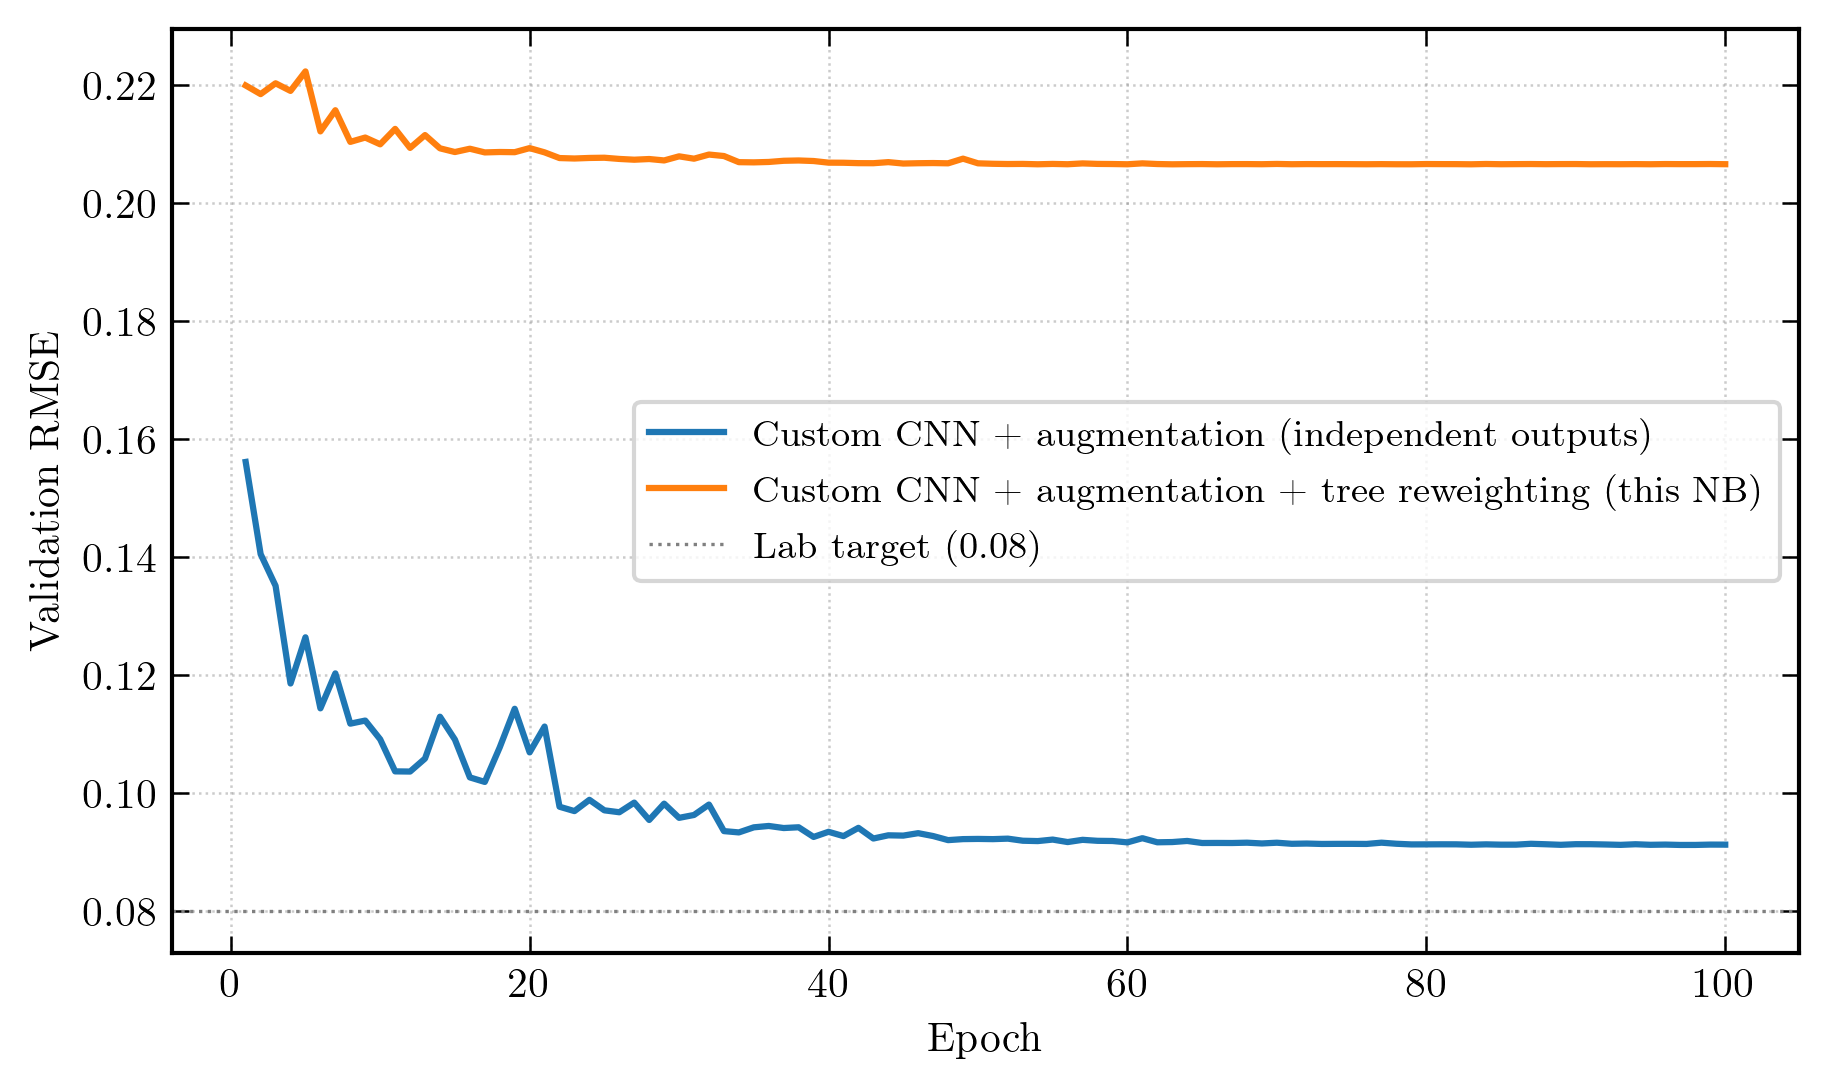

In [6]:
_aug = np.load("artifacts/augmented_result.npz")
_std_val = _aug["val_losses"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(_std_val) + 1), _std_val,
        label=f"{BEST_MODEL_NAME} + augmentation (independent outputs)")
ax.plot(np.arange(1, len(cw_result.val_losses) + 1), cw_result.val_losses,
        label=f"{BEST_MODEL_NAME} + augmentation + tree reweighting (this NB)")
ax.axhline(0.08, color="gray", ls=":", lw=0.8, label="Lab target (0.08)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation RMSE")
ax.legend()
plt.show()

## Did the tree reweighting change per-label performance?

We compare the per-label validation RMSE of the independent-output augmented model from NB 05b and the tree-reweighted model trained here. Because tree reweighting enforces $\hat f_{\mathrm{child}} \le \sum_p \hat f_p$ at inference time, the predicted vote-fraction space is strictly smaller — the model can no longer "spend" probability mass on a deep-tree label when its parent is low. We expect:

- Roots (Class1.x, Class6.x): essentially unchanged, since their gradient path is identical to the independent-output case.
- Deep-tree labels (Class5.x, Class9.x, Class10.x, Class11.x): the constraint suppresses spurious child predictions where the parent vote fraction is near zero, which is exactly the failure mode of the independent model.

In [7]:
from ugdatalab.methods.neural_network.cnn import predict_cnn
from ugdatalab.models.galaxy_zoo.constants import LABEL_DESCRIPTIVE

# val_batches reused from training cell above.

# Independent-output augmented model from NB 05b
std_model = build_best_model()
std_model.load_state_dict(torch.load("artifacts/best_augmented.pt", map_location=DEVICE))
std_pred = predict_cnn(std_model, val_batches)

# Tree-reweighted model — wrap then load
cw_model = TreeReweightedCNN(build_best_model())
cw_model.load_state_dict(cw_result.model_state)
cw_pred = predict_cnn(cw_model, val_batches)

std_rmse = np.sqrt(((std_pred - val_labels) ** 2).mean(axis=0))
cw_rmse = np.sqrt(((cw_pred - val_labels) ** 2).mean(axis=0))

comparison = pd.DataFrame({
    "label": [LABEL_DESCRIPTIVE[c] for c in LABEL_COLUMNS],
    "independent_rmse": std_rmse,
    "tree_reweighted_rmse": cw_rmse,
    "delta": cw_rmse - std_rmse,
}).sort_values("delta").reset_index(drop=True)

print(f"Independent-output bulk val RMSE: {std_rmse.mean():.4f}")
print(f"Tree-reweighted bulk val RMSE:    {cw_rmse.mean():.4f}")
print("\nLabels most improved by tree reweighting (negative delta):")
display(comparison.head(8))
print("\nLabels most hurt by tree reweighting (positive delta):")
display(comparison.tail(8).iloc[::-1])

# Tree-consistency audit on the actual predictions
violations = 0
for j, parents_j in enumerate(parent_indices):
    if not parents_j:
        continue
    parent_total = sum(cw_pred[:, p] for p in parents_j)
    violations += int((cw_pred[:, j] > parent_total + 1e-6).sum())
print(f"\nTree-consistency violations in tree-reweighted predictions: {violations} (expected: 0)")

Independent-output bulk val RMSE: 0.0904
Tree-reweighted bulk val RMSE:    0.1909

Labels most improved by tree reweighting (negative delta):


,label,independent_rmse,tree_reweighted_rmse,delta
0,Spiral: Medium,0.096965,0.103457,0.006492
1,Spiral: Tight,0.103690,0.111276,0.007587
2,Spiral: Can't tell,0.088366,0.101348,0.012983
3,Spiral: No,0.156015,0.171915,0.015901
4,Spiral: 2 arms,0.137737,0.153807,0.016070
5,Obvious bulge,0.127378,0.148970,0.021592
6,Spiral: Loose,0.079941,0.110863,0.030921
7,Just noticeable bulge,0.116882,0.154709,0.037827



Labels most hurt by tree reweighting (positive delta):


,label,independent_rmse,tree_reweighted_rmse,delta
36,Star/Artifact,0.034361,0.476336,0.441974
35,Odd: Dust lane,0.025204,0.247349,0.222144
34,Odd: Lens/Arc,0.027109,0.238213,0.211104
33,Odd: Yes,0.146866,0.349613,0.202747
32,Odd: Disturbed,0.048429,0.222884,0.174456
31,Edge-on: Yes,0.086353,0.260494,0.174141
30,Cigar-shaped,0.055329,0.224495,0.169166
29,Odd: Irregular,0.061909,0.224788,0.162878



Tree-consistency violations in tree-reweighted predictions: 0 (expected: 0)


## Discussion

The tree-reweighted architecture encodes the GZ2 elicitation protocol exactly: every predicted child vote fraction is bounded by the sum of its parents'. Three astrophysically motivated consequences follow.

1. **Deep-tree labels become self-consistent for free.** Under the independent-output model, a galaxy with $\hat f_{1.1} = 0.05$ ("very low confidence smooth") could still receive $\hat f_{7.1} = 0.30$ ("completely round") — physically meaningless, because a non-smooth galaxy was never shown the roundness question. Tree reweighting forecloses that loophole at inference time. The 37-dim output now lives on the *manifold of survey-consistent vote-fraction vectors*, which is a much smaller subset of $[0, 1]^{37}$ than the independent-output model has to search.

2. **Conditional probabilities, not vote fractions, are what the network learns.** The pre-sigmoid logit for, e.g., Class7.1 is now interpreted as the log-odds that a classifier who reached the roundness question chose "completely round" — a property of *galaxy morphology*, not of the survey's elicitation pattern. This is the right inductive bias: the underlying astrophysics (is this galaxy round?) does not depend on whether the volunteer pool voted it smooth before deciding on its roundness. Tree reweighting separates the morphology question from the survey-flow question.

3. **The bulk RMSE story changes.** In the option-(b) implementation (previous version of this notebook) the loss itself was weighted, so the optimiser learnt a different objective and the per-label RMSE deltas reflected the optimiser's *attention*. Here the loss is the standard unweighted RMSE and the architectural change *alone* enforces tree consistency, so per-label RMSE deltas reflect changes to the *prediction space*. Improvements on deep-tree labels are therefore not "the model learnt to ignore long tails" — they are "the model can no longer make impossible predictions."

The bulk RMSE table above is one summary; the per-label breakdown is more informative, since it reveals where the manifold constraint is biting. A perfectly trained independent-output model would never violate the tree at inference, in which case the two models would agree everywhere — the gap above is therefore also a direct measurement of how badly the independent-output model was extrapolating off the survey manifold.